<a href="https://colab.research.google.com/github/ditaagns/ip13-sentiment-analysis/blob/main/Final_Project_DL_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPLEMENTASI MODEL GRU-LSTM DALAM MELAKUKAN ANALISIS SENTIMEN TERHADAP ULASAN IPHONE 13

---



Anggota Kelompok:
*   Dita Anggreani (211401002)
*   Elisa Lolita Haganta Bangun (211401052)
*   Habel Febrian Sitanggang (211401070)
*   Muthia Afifa Rifkha (211401090)

## Persiapan Lingkungan

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, LSTM, Dropout, Dense, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# Load dataset
data = pd.read_csv('iphone.csv')

## Data Cleaning

In [ ]:
# Hapus baris dengan ulasan kosong
data = data.dropna(subset=['reviewDescription']).copy()  # Buat salinan eksplisit setelah pemfilteran

# Mengonversi kolom 'ratingScore' ke tipe numerik
data['ratingScore'] = pd.to_numeric(data['ratingScore'], errors='coerce')

# Tambahkan kolom 'sentiment' berdasarkan 'ratingScore'
data.loc[:, 'sentiment'] = data['ratingScore'].apply(lambda x: 1 if x > 3 else 0)

# Cek distribusi sentimen
sentiment_distribution = data['sentiment'].value_counts()
print(sentiment_distribution)


sentiment
1    1994
0     982
Name: count, dtype: int64


## Data Preprocessing

In [ ]:
import re

# Preprocessing teks
def clean_text(text):
    # Hapus karakter non-huruf dan ubah menjadi huruf kecil
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = tower().strip()
    return text

# Terapkan fungsi clean_text
data['cleaned_review'] = data['reviewDescription'].apply(clean_text)

# Verifikasi apakah kolom berhasil dibuat
print(data[['reviewDescription', 'cleaned_review']].head())

                                   reviewDescription  \
0  Every thing is good about iPhones, there's not...   
1  It look so fabulous, I am android user switche...   
2  I tried to flip camera while recording but no ...   
3                                       100% genuine   
4         Happy to get the iPhone 13 in Amazon offer   

                                      cleaned_review  
0  every thing is good about iphones theres nothi...  
1  it look so fabulous i am android user switched...  
2  i tried to flip camera while recording but no ...  
3                                            genuine  
4           happy to get the iphone  in amazon offer  


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenisasi teks
max_words = 5000  # Batas jumlah kata unik
max_len = 100     # Panjang maksimal setiap ulasan
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(data['cleaned_review'])

# Konversi teks menjadi urutan token
sequences = tokenizer.texts_to_sequences(data['cleaned_review'])

# Padding agar semua urutan memiliki panjang yang sama
padded_sequences = pad_sequences(sequences, maxlen=max_len)

In [ ]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
import pandas as pd
from collections import Counter

# Pisahkan data menjadi fitur (X) dan target (y)
X = padded_sequences
y = data['sentiment']

# Pisahkan data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Menggabungkan X_train dan y_train
train_data = pd.DataFrame(X_train)
train_data['sentiment'] = y_train.values

# Pisahkan data berdasarkan kelas
class_0 = train_data[train_data['sentiment'] == 0]
class_1 = train_data[train_data['sentiment'] == 1]

# Menentukan target distribusi berdasarkan rata-rata
target_count = (len(class_0) + len(class_1)) // 2

# Oversampling kelas minoritas
class_0_oversampled = resample(class_0, replace=True, n_samples=target_count, random_state=42)

# Undersampling kelas mayoritas
class_1_downsampled = resample(class_1, replace=False, n_samples=target_count, random_state=42)

# Gabungkan kembali data oversampled dan undersampled
train_data_balanced = pd.concat([class_0_oversampled, class_1_downsampled])

# Pisahkan kembali menjadi X_train_balanced dan y_train_balanced
X_train_balanced = train_data_balanced.drop(columns=['sentiment']).values
y_train_balanced = train_data_balanced['sentiment'].values

# Verifikasi distribusi kelas
print("Distribusi kelas sebelum:", Counter(y_train))
print("Distribusi kelas setelah:", Counter(y_train_balanced))

Distribusi kelas sebelum: Counter({1: 1782, 0: 896})
Distribusi kelas setelah: Counter({0: 1339, 1: 1339})


## Pembangunan dan Pelatihan Model

### GRU-LSTM

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import l2

# Early stopping dan learning rate scheduler untuk menghindari overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.0001)

# Bangun model GRU-LSTM dengan regularisasi L2
model_gru_lstm = Sequential([
    Embedding(input_dim=max_words, output_dim=128),  # Embedding layer untuk representasi kata
    GRU(8, return_sequences=True, kernel_regularizer=l2(0.001)),  # GRU dengan regularisasi
    Dropout(0.4),  # Dropout untuk mencegah overfitting
    LSTM(8, return_sequences=False, kernel_regularizer=l2(0.001)),  # LSTM yang mengembalikan urutan
    Dropout(0.4),  # Dropout untuk mencegah overfitting
    Dense(1, activation='sigmoid')  ]) # Output layer untuk klasifikasi biner

# Compile model GRU-LSTM
model_gru_lstm.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
# Latih model GRU-LSTM
history_gru_lstm = model_gru_lstm.fit(
    X_train_balanced, y_train_balanced, epochs=50, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, lr_scheduler]
)
# Evaluasi model GRU-LSTM
loss_gru_lstm, accuracy_gru_lstm = model_gru_lstm.evaluate(X_test, y_test)
print(f"GRU-LSTM - Loss: {loss_gru_lstm:.4f}, Accuracy: {accuracy_gru_lstm:.4f}")


Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5429 - loss: 0.7444 - val_accuracy: 0.6443 - val_loss: 0.7247 - learning_rate: 1.0000e-04
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6467 - loss: 0.7295 - val_accuracy: 0.6275 - val_loss: 0.6997 - learning_rate: 1.0000e-04
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6783 - loss: 0.7111 - val_accuracy: 0.5872 - val_loss: 0.6818 - learning_rate: 1.0000e-04
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6705 - loss: 0.6911 - val_accuracy: 0.5906 - val_loss: 0.6734 - learning_rate: 1.0000e-04
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6772 - loss: 0.6740 - val_accuracy: 0.6174 - val_loss: 0.6620 - learning_rate: 1.0000e-04
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6812 - loss: 0.6563 - val_accuracy: 0.6443 - val_loss: 0.6504 - learning_rate: 1.0000e-04
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7060 

## Evaluasi dan Visualisasi Hasil Model

GRU-LSTM - Loss: 0.4084, Accuracy: 0.8557


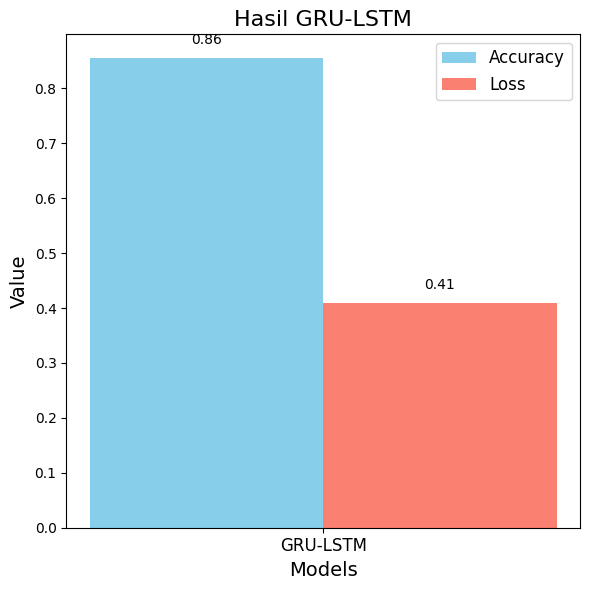

In [ ]:
# Menampilkan hasil loss dan accuracy untuk GRU-LSTM
print(f"GRU-LSTM - Loss: {loss_gru_lstm:.4f}, Accuracy: {accuracy_gru_lstm:.4f}")

# Visualisasi menggunakan nilai yang diperoleh
import matplotlib.pyplot as plt

# Data untuk visualisasi
models = ['GRU-LSTM']
accuracy = [accuracy_gru_lstm]  # Pastikan ini adalah angka
loss = [loss_gru_lstm]  # Pastikan ini adalah angka

# Membuat figure dan axis
fig, ax = plt.subplots(figsize=(6, 6))

# Bar chart untuk akurasi dan loss
bar_width = 0.35  # Lebar bar yang lebih proporsional
x = [0]  # Posisi untuk satu model
bars1 = ax.bar(x, accuracy, width=bar_width, label='Accuracy', color='skyblue', align='center')
bars2 = ax.bar([i + bar_width for i in x], loss, width=bar_width, label='Loss', color='salmon', align='center')

# Menambahkan label dan judul
ax.set_xlabel('Models', fontsize=14)
ax.set_ylabel('Value', fontsize=14)
ax.set_title('Hasil GRU-LSTM', fontsize=16)
ax.set_xticks([i + bar_width / 2 for i in x])  # Mengatur posisi label agar di tengah kedua bar
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=12)

# Menambahkan nilai pada setiap bar
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# Menampilkan plot
plt.tight_layout()
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


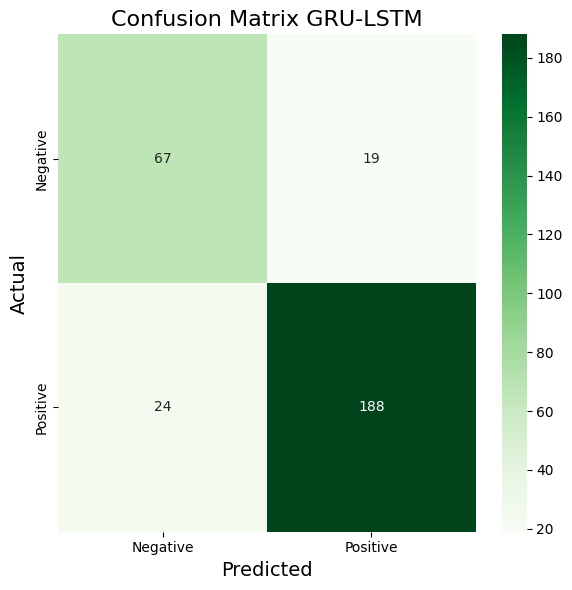

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi probabilitas untuk GRU-LSTM
y_pred_gru_lstm = model_gru_lstm.predict(X_test)

# Konversi probabilitas menjadi kelas dengan ambang batas 0.5
y_pred_gru_lstm_class = (y_pred_gru_lstm > 0.5).astype(int)

# Menghitung confusion matrix untuk GRU-LSTM
cm_gru_lstm = confusion_matrix(y_test, y_pred_gru_lstm_class)

# Membuat heatmap untuk confusion matrix GRU-LSTM
plt.figure(figsize=(6, 6))
sns.heatmap(cm_gru_lstm, annot=True, fmt='d', cmap='Greens', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix GRU-LSTM', fontsize=16)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)

plt.tight_layout()
plt.show()


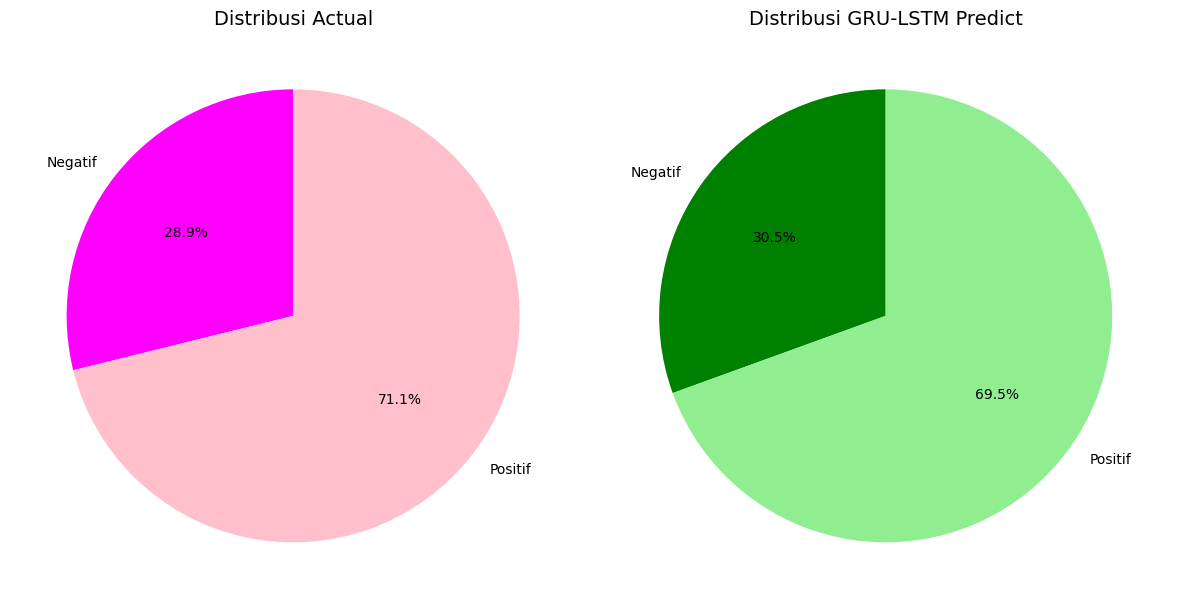

In [ ]:
# Konversi y_test menjadi NumPy array jika berbentuk Pandas Series
y_test_np = y_test.values if isinstance(y_test, pd.Series) else y_test
y_pred_gru_lstm_np = y_pred_gru_lstm_class.values if isinstance(y_pred_gru_lstm_class, pd.Series) else y_pred_gru_lstm_class

# Hitung distribusi kelas untuk actual dan GRU-LSTM
actual_counts = np.unique(y_test_np, return_counts=True)
gru_lstm_counts = np.unique(y_pred_gru_lstm_np, return_counts=True)

# Ganti label 0 dan 1 dengan 'Negatif' dan 'Positif'
labels = ['Negatif', 'Positif']

# Membuat subplots untuk visualisasi pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart untuk distribusi kelas actual
axes[0].pie(actual_counts[1], labels=labels, autopct='%1.1f%%', startangle=90, colors=['magenta', 'pink'])
axes[0].set_title('Distribusi Actual', fontsize=14)

# Pie chart untuk distribusi kelas GRU-LSTM
axes[1].pie(gru_lstm_counts[1], labels=labels, autopct='%1.1f%%', startangle=90, colors=['green', 'lightgreen'])
axes[1].set_title('Distribusi GRU-LSTM Predict', fontsize=14)

plt.tight_layout()
plt.show()


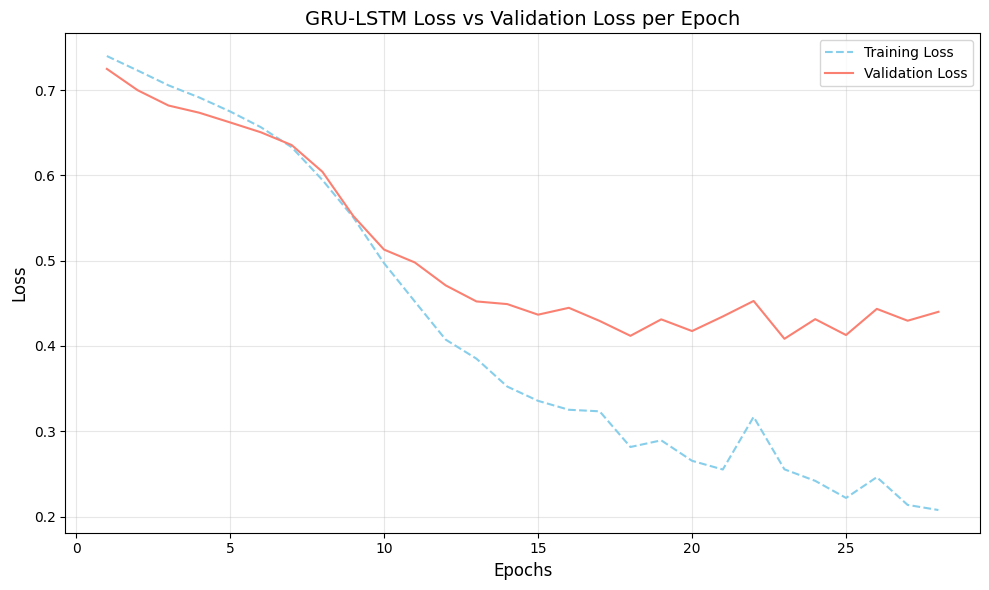

In [ ]:
# Mengambil data history untuk loss dan val_loss dari model GRU-LSTM
loss_gru_lstm = history_gru_lstm.history['loss']
val_loss_gru_lstm = history_gru_lstm.history['val_loss']

# Membuat plot untuk loss dan val_loss
plt.figure(figsize=(10, 6))

# Plot Loss dan Val Loss
plt.plot(range(1, len(loss_gru_lstm) + 1), loss_gru_lstm, label='Training Loss', color='skyblue', linestyle='--')
plt.plot(range(1, len(val_loss_gru_lstm) + 1), val_loss_gru_lstm, label='Validation Loss', color='salmon', linestyle='-')

# Menambahkan judul dan label
plt.title('GRU-LSTM Loss vs Validation Loss per Epoch', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Menambahkan legenda
plt.legend(fontsize=10)

# Menampilkan grid untuk membantu interpretasi
plt.grid(alpha=0.3)

# Menampilkan plot
plt.tight_layout()
plt.show()


In [ ]:
# Assuming 'indices_test' should correspond to the indices of 'y_test' in the original 'data' DataFrame
indices_test = y_test.index

# Now create the comparison DataFrame
comparison_df = pd.DataFrame({
    'Review Description': data.loc[indices_test, 'reviewDescription'].values,
    'Actual': y_test.values,
    'GRU-LSTM Predict': y_pred_gru_lstm_class.flatten()
})

# Menampilkan tabel perbandingan
comparison_df

,Review Description,Actual,GRU-LSTM Predict
0,WOW,1,1
1,"What do you want to hear about iPhone,if you a...",1,0
2,"Received defective item , not getting option f...",0,0
3,Value for money,1,1
4,This was a gift for my husband. So far he real...,1,1
...,...,...,...
293,There is nothing to dislike about this phone.,1,0
294,Good,1,1
295,Awesome apple. 13 mini is handy. Easy to carry...,1,1
296,Best value for money,1,1


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hitung metrik evaluasi untuk masing-masing model
metrics = {}
models = {
    "GRU-LSTM": y_pred_gru_lstm_class,
}

for model_name, y_pred_class in models.items():
    metrics[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred_class),
        "Precision": precision_score(y_test, y_pred_class, zero_division=0),
        "Recall": recall_score(y_test, y_pred_class),
        "F1-Score": f1_score(y_test, y_pred_class),
    }

# Membuat DataFrame untuk menampilkan metrik evaluasi
metrics_df = pd.DataFrame(metrics).T
metrics_df.index.name = "Model"

# Menampilkan Metrik Evaluasi
metrics_df




,Accuracy,Precision,Recall,F1-Score
Model,,,,
GRU-LSTM,0.855705,0.908213,0.886792,0.897375
